In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(
    "zahn.csv",
    sep="\t",
    header=None,
    names=["X", "Y", "Clase"]
)

df.head()

,X,Y,Clase
0,26.75,22.15,0
1,29.80,22.15,0
2,31.55,21.10,0
3,27.70,20.85,0
4,29.90,19.95,0


In [5]:
df.info()

df["Clase"].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       399 non-null    float64
 1   Y       399 non-null    float64
 2   Clase   399 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


Clase
0     50
1     92
2     83
3    158
4     16
Name: count, dtype: int64

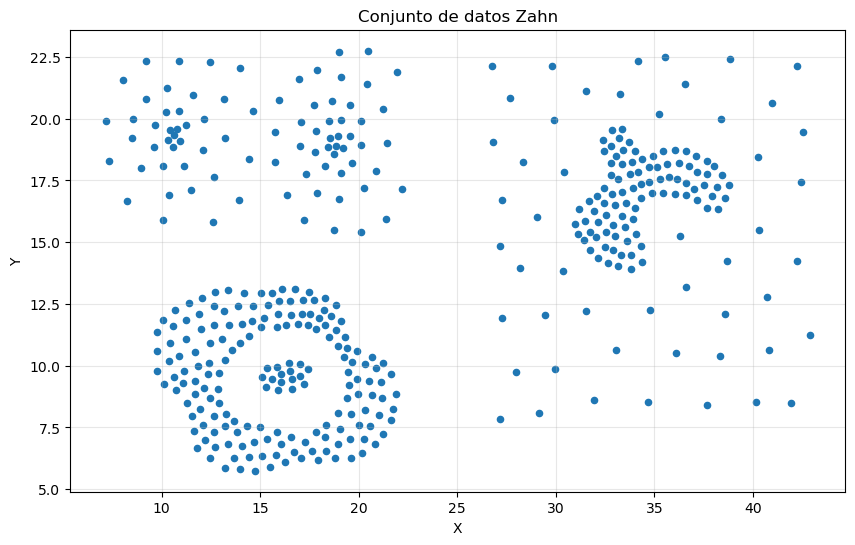

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["X"],
    df["Y"],
    s=20
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Conjunto de datos Zahn")
plt.grid(alpha=0.3)

plt.show()

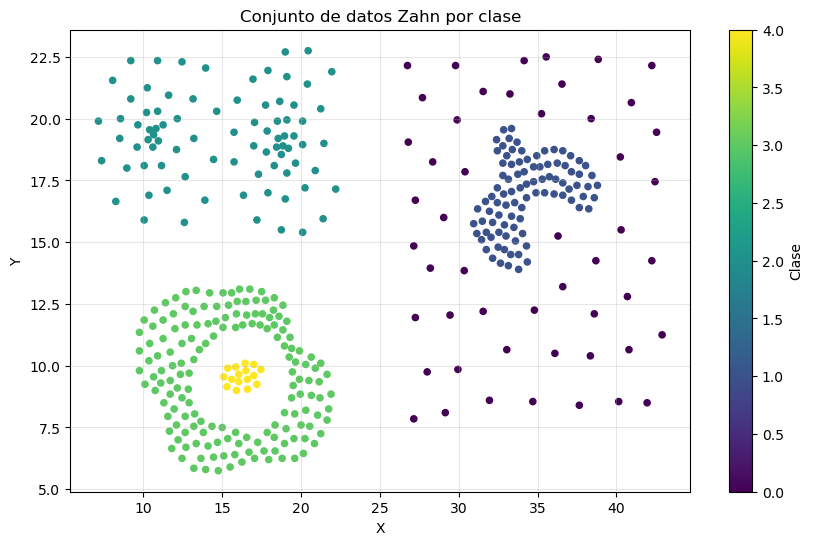

In [7]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["X"],
    df["Y"],
    c=df["Clase"],
    s=20
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Conjunto de datos Zahn por clase")
plt.colorbar(scatter, label="Clase")
plt.grid(alpha=0.3)

plt.show()

# Punto 1: Encontrar el diametro del espacio, DIAM(Z):
Procedimiento:
1. Se calcula la distancia Euclidiana (diametro) entre cada vector.
2. Se campara cada una para encontrar la distancia mas larga entre 2 vectores
3. Se reporta el hayazgo.

In [8]:
import numpy as np
from scipy.spatial.distance import cdist

# Tomamos únicamente las columnas X y Y
Z = df[["X", "Y"]].to_numpy()

# Matriz de distancias euclidianas entre todos los vectores
distancias = cdist(Z, Z, metric="euclidean")

print(distancias.shape)

(399, 399)


In [9]:
distancias[:5, :5]

array([[0.        , 3.05      , 4.91350181, 1.61012422, 3.84219989],
       [3.05      , 0.        , 2.04083316, 2.46981781, 2.20227155],
       [4.91350181, 2.04083316, 0.        , 3.85810834, 2.01121854],
       [1.61012422, 2.46981781, 3.85810834, 0.        , 2.37697286],
       [3.84219989, 2.20227155, 2.01121854, 2.37697286, 0.        ]])

In [10]:
# Busca el elemento mas grande de toda la matriz de distancias

Diam_Z = np.max(distancias)

print(f"Diámetro de Z: {Diam_Z:.4f}")

Diámetro de Z: 36.7816


In [11]:
# Muestra cuales son los vectores que generan el diámetro de Z
i, j = np.unravel_index(
    np.argmax(distancias),
    distancias.shape
)

print("Índice del primer vector:", i)
print("Índice del segundo vector:", j)

print("Vector 1:", Z[i])
print("Vector 2:", Z[j])

Índice del primer vector: 36
Índice del segundo vector: 152
Vector 1: [42.9  11.25]
Vector 2: [ 7.15 19.9 ]


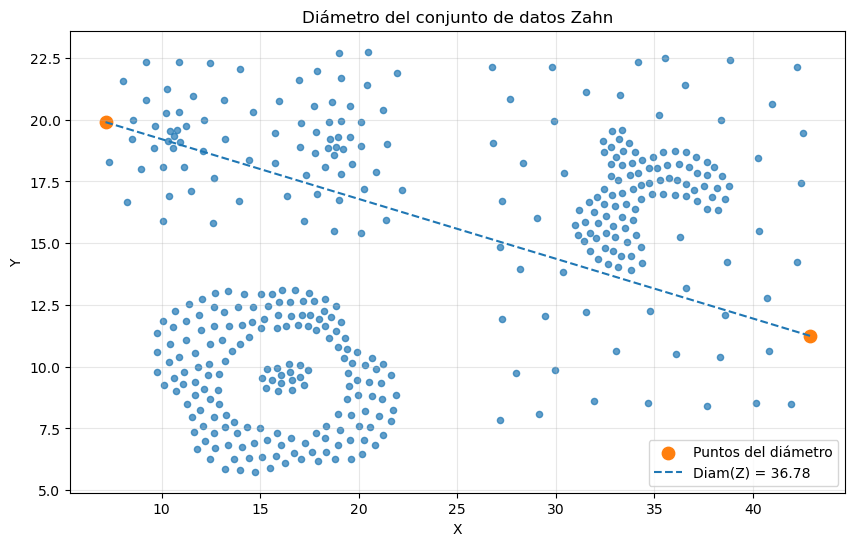

In [12]:
# Graficamos el diametro de Z

plt.figure(figsize=(10, 6))

# Todos los datos
plt.scatter(
    df["X"],
    df["Y"],
    s=20,
    alpha=0.7
)

# Puntos que generan el diámetro
plt.scatter(
    [Z[i, 0], Z[j, 0]],
    [Z[i, 1], Z[j, 1]],
    s=80,
    label="Puntos del diámetro"
)

# Línea correspondiente al diámetro
plt.plot(
    [Z[i, 0], Z[j, 0]],
    [Z[i, 1], Z[j, 1]],
    linestyle="--",
    label=f"Diam(Z) = {Diam_Z:.2f}"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Diámetro del conjunto de datos Zahn")
plt.legend()
plt.grid(alpha=0.3)

plt.show()